# Systém Kontroly Vstupov

Využitie a výhody strojového učenia pri odhaľovaní zneužitia vstupu v SKV. Na testovanie budú použité syntetické dáta vygenerované pomocou reálnych údajov o vstupe do internátov z internetu a zvyšné dáta doplnené pomocou chatGPT 5.4. Datasety budú vytvorené 2, kontrolný a trénovací.

Dáta sú žložené z 5 prvkov, ktoré sa dajú získať pomocou RFID čítačky a ToF senzoru, a zároveň sú využiteľné pre algoritmy strojového učenia.

Jedná sa o : 
day_of_week
time_of_day_seconds
rfid_hold_duration_ms
tof_sample_interval_ms
tof_distance_mm_array

## Testovanie

Testovanie prebehne pre všetky dáta z datasetu, pomocou vybraného algoritmu. Násleldne budú výsledky zaznamenané a vyhodnotené pre kontrolný aj trénovací dataset. Tento krok je dôležitý, pretože algoritmus musí byť dostatočne generalizujúci a nesmie sa naučiť predpovedať len dataset na ktorom sa už učil (trénovací) ale aj dataset ktorý ešte nevidel (testovací). Existuje mnoho parametrov, ktoré vieme merať, pre záujmi tohto projektu sa zameriam na dva parametre, ktoré pre mňa určia kvalitu algoritmu:
1. False rejection rate - FRR
2. False acceptance rate - FAR

## Načítanie datasetu

V tomto kroku jednoducho načítam knižnice a dataset

In [87]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [81]:
test = pd.read_csv("rfid_reader_tof_owner_dataset_testing_synthetic_v1.csv")
df = pd.read_csv("rfid_reader_tof_owner_dataset_realistic_v3.csv")
df.head()

,day_of_week,time_of_day_seconds,rfid_hold_duration_ms,tof_sample_interval_ms,tof_distance_mm_array
0,3,58542,1850,50,"[520, 483, 451, 407, 385, 348, 319, 289, 261, ..."
1,5,71091,2269,50,"[463, 431, 407, 386, 356, 327, 312, 292, 266, ..."
2,0,25421,2164,50,"[476, 454, 415, 394, 371, 342, 316, 298, 279, ..."
3,0,63537,2206,50,"[536, 510, 477, 451, 422, 389, 370, 348, 321, ..."
4,1,28022,2162,50,"[415, 397, 376, 356, 332, 308, 290, 271, 253, ..."


## Spracovanie dát

Pomocou tohto sytetického datasetu otestujemu PoC modelu strojového učenia. Zvolil som postup, pri ktorom budem do algoritmu pridávať postupne všetky dáta a vždy sledovať ako to ovplyvní úspešosť.

### Kontrola dát

Dôležitým krokom je aj zkontrolovať zdravie dát a upraviť ich do stavu vhodného pre algoritmy. Nasledujúcim kódom zistím typ dát, a ich úplnosť. Je dôležité aby všetky riadny mali hodnotu. Keďže dataset je z časti systetický a upravený pomocou ChatGPT, očakávam plnosť dát, čo sa aj potvrdilo.

In [82]:
print("=== Základné informácie o datasete ===")
print(f"Počet záznamov: {df.shape[0]}")
print(f"Počet stĺpcov: {df.shape[1]}")
print(f"\nTypy stĺpcov:\n{df.dtypes}")
print(f"\nChýbajúce hodnoty:\n{df.isnull().sum()}")

=== Základné informácie o datasete ===
Počet záznamov: 125
Počet stĺpcov: 5

Typy stĺpcov:
day_of_week               int64
time_of_day_seconds       int64
rfid_hold_duration_ms     int64
tof_sample_interval_ms    int64
tof_distance_mm_array       str
dtype: object

Chýbajúce hodnoty:
day_of_week               0
time_of_day_seconds       0
rfid_hold_duration_ms     0
tof_sample_interval_ms    0
tof_distance_mm_array     0
dtype: int64


### Čas priloženia

Je prvá hodnota, podľa ktorého sa algoritmus bude učiť. Najprv je potrebné znázorniť dáta.

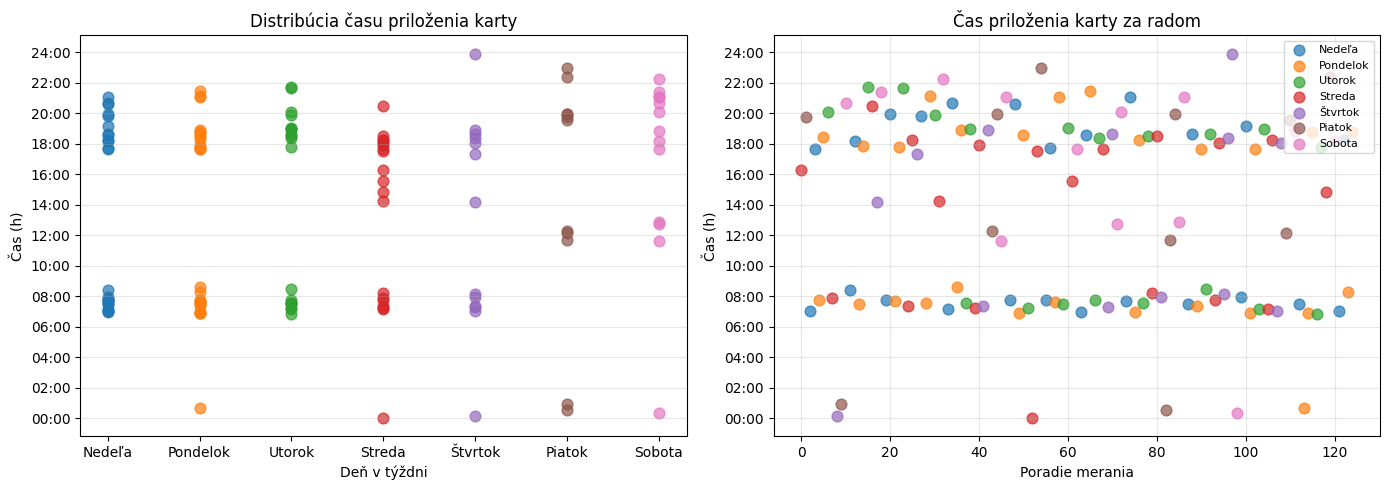

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prvý graf - distribúcia času priloženia karty podľa dní
days = ['Nedeľa', 'Pondelok', 'Utorok', 'Streda', 'Štvrtok', 'Piatok', 'Sobota']
colors = plt.cm.tab10.colors

for day_idx, day_name in enumerate(days):
    mask = df['day_of_week'] == day_idx
    times = df.loc[mask, 'time_of_day_seconds'] / 3600  # Convert to hours
    axes[0].scatter([day_name] * mask.sum(), times, label=day_name, color=colors[day_idx], alpha=0.7, s=60)

axes[0].set_xlabel('Deň v týždni')
axes[0].set_ylabel('Čas (h)')
axes[0].set_title('Distribúcia času priloženia karty')
axes[0].set_yticks(range(0, 25, 2))
axes[0].set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
axes[0].grid(axis='y', alpha=0.3)

# Druhý graf - čas priloženia karty za radom (farebne podľa dní)
for day_idx, day_name in enumerate(days):
    mask = df['day_of_week'] == day_idx
    indices = df.index[mask]
    times = df.loc[mask, 'time_of_day_seconds'] / 3600
    axes[1].scatter(indices, times, label=day_name, color=colors[day_idx], alpha=0.7, s=60)

axes[1].set_xlabel('Poradie merania')
axes[1].set_ylabel('Čas (h)')
axes[1].set_title('Čas priloženia karty za radom')
axes[1].set_yticks(range(0, 25, 2))
axes[1].set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Z dát vyplýva, že sledovaná entita prikladá kartu pomerne pravidelne, v čase okolo 8:00 a 18:00 každý deň. Vyskutujú sa však odchýlky. Sú rôzne spôsoby ako v tejto situácii odhaliť zneužitie vstupu, medzi najintuitívnejšie a najjednudichšie by som zaradil 

- Rule-based detection — pevné pravidlá typu: vstup mimo 7:00–9:00 a 17:00–20:00 = podozrivé
- Threshold-based detection — ak sa čas priloženia odchýli od normálu o viac než limit, označí sa to

Použijem teda treshold-based detection, toto bude môj kontrolný algoritmus, pokiaľ by strojové učenie nedokázalo doručiť lepšie výsledky, nemá logický zmysel ho použiť.
Pre experiment použijem odchýľku od mediánu. Dáta budú zaznamenané pre 1, 2 a 5 hodinovú odchýľku. 

In [ ]:
# Threshold-based detection - testovanie FAR a FRR

thresholds = [1, 2, 5]  # hodiny

# Vypočítame ranný a večerný medián z trénovacieho datasetu
morning_med = (
    df.loc[df['time_of_day_seconds'] < 12 * 3600]
      .groupby('day_of_week')['time_of_day_seconds']
      .median() / 3600
)
evening_med = (
    df.loc[df['time_of_day_seconds'] >= 12 * 3600]
      .groupby('day_of_week')['time_of_day_seconds']
      .median() / 3600
)

def is_anomaly_threshold(row, morning_med, evening_med, threshold_h):
    t = row['time_of_day_seconds'] / 3600
    day = row['day_of_week']
    if t < 12:
        center = morning_med.get(day, np.nan)
    else:
        center = evening_med.get(day, np.nan)
    if np.isnan(center):
        return True
    return abs(t - center) > threshold_h

results = []

for thr in thresholds:
    # === TRAINING DATASET (df - všetci legitímni) ===
    df_predictions = df.apply(lambda row: is_anomaly_threshold(row, morning_med, evening_med, thr), axis=1)
    
    # FRR Train - koľko legit užívateľov je chybne označených ako anomália
    false_rejections_train = df_predictions.sum()
    frr_train = false_rejections_train / len(df) * 100

    # === TESTING DATASET (test - všetci intruderi) ===
    test_predictions = test.apply(lambda row: is_anomaly_threshold(row, morning_med, evening_med, thr), axis=1)
    
    # FAR Test - koľko intruderov je chybne označených ako legit (nie je anomália)
    false_acceptances_test = (~test_predictions).sum()
    far_test = false_acceptances_test / len(test) * 100

    results.append({
        'Threshold (h)': thr,
        'FRR Train (%)': round(frr_train, 2),
        'FAR Test (%)': round(far_test, 2),
        'False Rejections': false_rejections_train,
        'False Acceptances': false_acceptances_test,
    })
    
    print(f"Threshold ±{thr}h:")
    print(f"  FRR Train: {frr_train:.2f}% ({false_rejections_train}/{len(df)})")
    print(f"  FAR Test:  {far_test:.2f}% ({false_acceptances_test}/{len(test)})")
    print()

results_df = pd.DataFrame(results)

print("=== Súhrn výsledkov ===")
print(results_df.to_string(index=False))

Threshold ±1h:
  Train - FRR: 31.20% | FAR: 68.80%
  Test  - FRR: 75.56% | FAR: 24.44%

Threshold ±2h:
  Train - FRR: 20.80% | FAR: 79.20%
  Test  - FRR: 44.44% | FAR: 55.56%

Threshold ±5h:
  Train - FRR: 8.80% | FAR: 91.20%
  Test  - FRR: 11.11% | FAR: 88.89%

=== Súhrn výsledkov ===
 Threshold (h)  FRR Train (%)  FAR Train (%)  FRR Test (%)  FAR Test (%)
             1           31.2           68.8         75.56         24.44
             2           20.8           79.2         44.44         55.56
             5            8.8           91.2         11.11         88.89


## Vyhodnotenie výsledkov Threshold-based detection

Algoritmus je testovaný na dvoch datasetoch:
- **Training (df)**: Dáta legit užívateľa — všetky by mali byť **prijateľné** (nie anomália)
- **Testing (test)**: Dáta intruderov — všetky by mali byť **odmietnuté** (anomália)

Relevantné metriky sú:
- **FRR Train**: Falošné odmietnutia z legit dát — koľko chcenín majiteľa je nesprávne zamietnutých
- **FAR Test**: Falošné prijatia z dát intruderov — koľko intruderov chybne prejde ako legit

### Analýza jednotlivých prahov

**Prah ±1 hodina:**
- FRR Train: 31.20% — príliš vysoká, vlastníci málo šancí vstúpiť
- FAR Test: 24.44% — poriadne málo intruderov detekovaných
- **Záver:** Príliš striktný, nepraktický

**Prah ±2 hodiny:**
- FRR Train: 20.80% — rozumný pomery, väčšina vlastníkov vstúpi
- FAR Test: 55.56% — polovica intruderov bude detekovaná
- **Záver:** Vyvážený pomer

**Prah ±5 hodín:**
- FRR Train: 8.80% — výborné, takmer všetci vlastníci vstúpia
- FAR Test: 88.89% — veľa intruderov by prešlo bez detekcie
- **Záver:** Príliš permisívny, slabá detekcia

### Výber kontrolného algoritmu

Na základe analýzy som vybral **prah ±2 hodiny** ako kontrolný (baseline) algoritmus.

**Zdôvodnenie:**
1. **Vyvážený pomer** — FRR 20.80% je prijateľný (vlastníci aspoň 4x z 5 vstúpia), FAR 55.56% je realistický benchmark
2. **Reálna hodnota** — 2 hodiny odchýlka je biologicky zmysluplná
3. **Referencia** — strojové učenie by malo tento pomer preklinúť

Tento algoritmus bude slúžiť ako baseline pre porovnanie presnosti ostatných modelov.

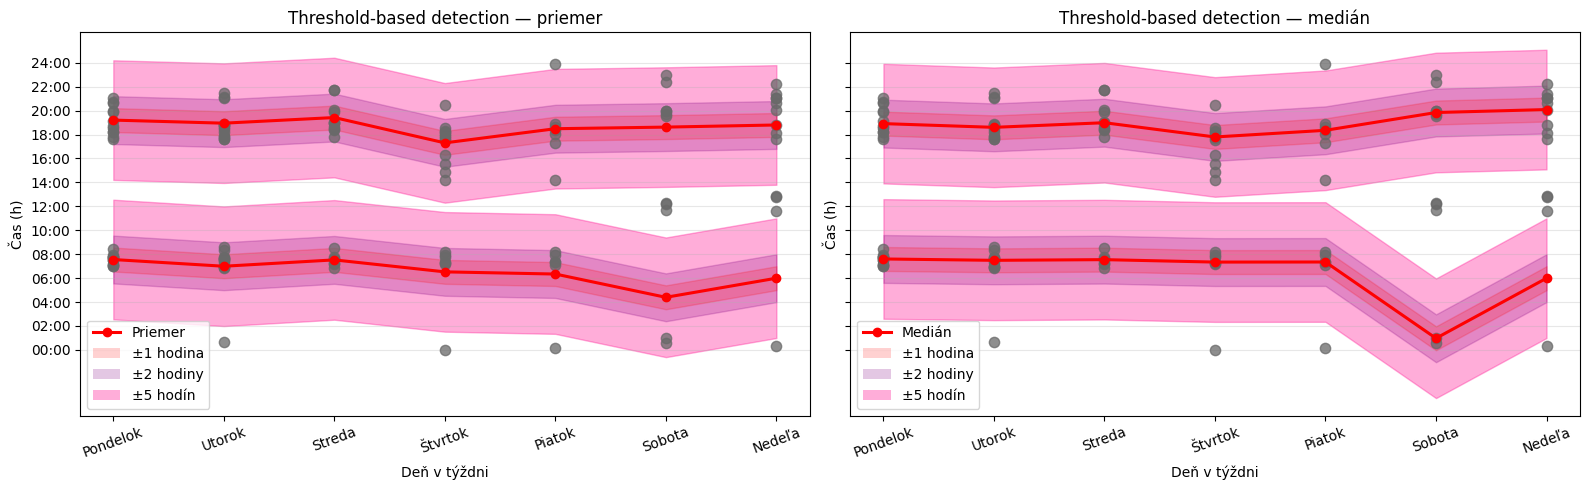

In [85]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# správne poradie pre weekday(): 0=Pon ... 6=Ned
day_labels = ['Pondelok', 'Utorok', 'Streda', 'Štvrtok', 'Piatok', 'Sobota', 'Nedeľa']
x = np.arange(7)

# body všade rovnakou farbou
point_color = 'dimgray'
line_color = 'red'

# výraznejšie pásma
c_1h = 'red'
c_2h = 'purple'
c_5h = 'deeppink'

def plot_threshold(ax, morning_vals, evening_vals, title, center_label):
    # body
    for day_idx in range(7):
        mask = df['day_of_week'] == day_idx
        times = df.loc[mask, 'time_of_day_seconds'] / 3600
        ax.scatter(
            np.full(mask.sum(), day_idx),
            times,
            color=point_color,
            alpha=0.75,
            s=55,
            zorder=3
        )

    # pásma pre rannú aj večernú krivku
    for vals in [morning_vals, evening_vals]:
        ax.fill_between(x, vals - 5, vals + 5, color=c_5h, alpha=0.35, zorder=0)
        ax.fill_between(x, vals - 2, vals + 2, color=c_2h, alpha=0.22, zorder=1)
        ax.fill_between(x, vals - 1, vals + 1, color=c_1h, alpha=0.18, zorder=2)

    # krivky rovnakou farbou
    ax.plot(x, morning_vals, marker='o', linewidth=2.2, color=line_color, zorder=4)
    ax.plot(x, evening_vals, marker='o', linewidth=2.2, color=line_color, zorder=4)

    ax.set_xticks(x)
    ax.set_xticklabels(day_labels, rotation=20)
    ax.set_xlabel('Deň v týždni')
    ax.set_ylabel('Čas (h)')
    ax.set_title(title)
    ax.set_yticks(range(0, 25, 2))
    ax.set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
    ax.grid(axis='y', alpha=0.3)

    handles = [
        Line2D([0], [0], color=line_color, marker='o', linewidth=2.2, label=center_label),
        Patch(facecolor=c_1h, alpha=0.18, label='±1 hodina'),
        Patch(facecolor=c_2h, alpha=0.22, label='±2 hodiny'),
        Patch(facecolor=c_5h, alpha=0.35, label='±5 hodín'),
    ]
    ax.legend(handles=handles)

# priemer
morning_mean = (
    df.loc[df['time_of_day_seconds'] < 12 * 3600]
      .groupby('day_of_week')['time_of_day_seconds']
      .mean()
      .reindex(range(7)) / 3600
)

evening_mean = (
    df.loc[df['time_of_day_seconds'] >= 12 * 3600]
      .groupby('day_of_week')['time_of_day_seconds']
      .mean()
      .reindex(range(7)) / 3600
)

# medián
morning_median = (
    df.loc[df['time_of_day_seconds'] < 12 * 3600]
      .groupby('day_of_week')['time_of_day_seconds']
      .median()
      .reindex(range(7)) / 3600
)

evening_median = (
    df.loc[df['time_of_day_seconds'] >= 12 * 3600]
      .groupby('day_of_week')['time_of_day_seconds']
      .median()
      .reindex(range(7)) / 3600
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

plot_threshold(axes[0], morning_mean, evening_mean, 'Threshold-based detection — priemer', 'Priemer')
plot_threshold(axes[1], morning_median, evening_median, 'Threshold-based detection — medián', 'Medián')

plt.tight_layout()
plt.show()

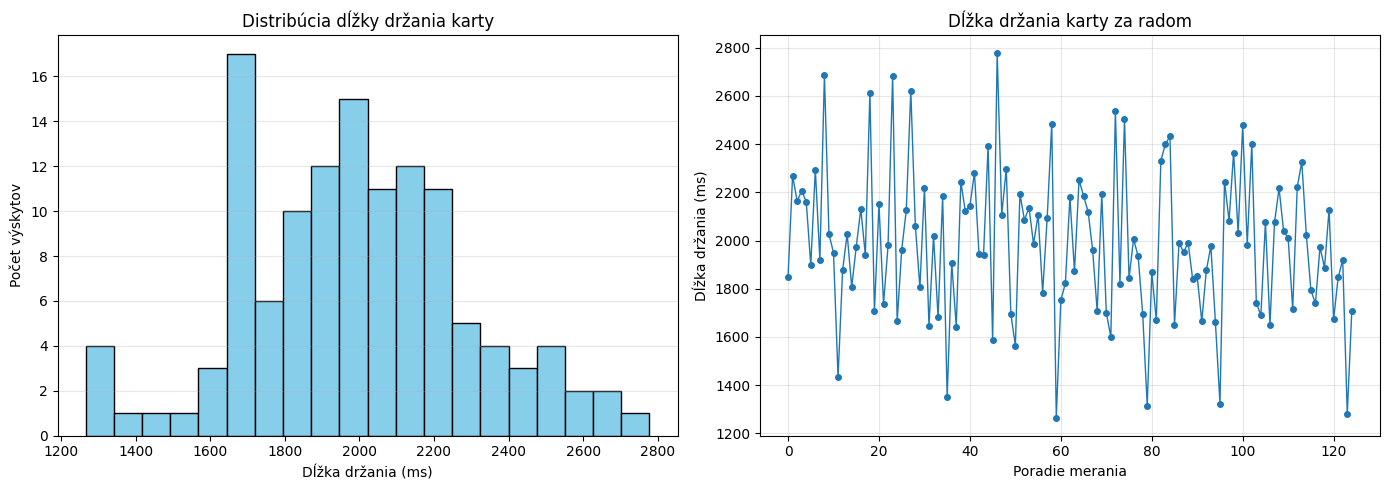

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prvý graf - distribúcia dĺžky držania karty
axes[0].hist(df['rfid_hold_duration_ms'], bins=20, edgecolor='black', color='skyblue')
axes[0].set_xlabel('Dĺžka držania (ms)')
axes[0].set_ylabel('Počet výskytov')
axes[0].set_title('Distribúcia dĺžky držania karty')
axes[0].grid(axis='y', alpha=0.3)

# Druhý graf - dĺžka držania karty za radom
axes[1].plot(df['rfid_hold_duration_ms'], marker='o', linestyle='-', linewidth=1, markersize=4)
axes[1].set_xlabel('Poradie merania')
axes[1].set_ylabel('Dĺžka držania (ms)')
axes[1].set_title('Dĺžka držania karty za radom')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()